## Modelado con Gaussian Mixture Model (GMM)


In [3]:
from sklearn.metrics import silhouette_score, silhouette_samples
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import plotly.express as px
from sklearn.mixture import GaussianMixture
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
import warnings
from math import pi
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')


### Preparacion de datos

In [4]:
df_clustering = pd.read_csv('df_clustering_models.csv')
df_nutrients = pd.read_csv('df_nutrients_models.csv')

''' 
df_demo = pd.read_csv('df_dem_general.csv', delimiter=';')
df_clustering = df_clustering.drop(columns=['energ_kcal', 'carbohydrt', 'lipid_tot', 'protein', 'fiber_td', 'calcium', 'iron', 'ironhem', 
                                             'ironnohem', 'zinc', 'vit_c', 'thiamin', 'riboflavin', 'niacin', 'panto_acid', 'vit_b6', 'folic_acid', 
                                             'food_folate', 'folate_dfe', 'vit_b12', 'vit_a_rae', 'vit_e', 'vit_d_iu', 'vit_k', 'fa_sat', 'fa_mono', 
                                             'fa_poly', 'chole', 'carbohydrt_ratio', 'lipid_tot_ratio', 'protein_ratio', 'poly_ratio', 'mono_ratio'])
df_demo = df_demo.drop(columns=['entidad', 'desc_ent', 'municipio', 'desc_mun', 'region', 'peso_tortilla_maiz', 'peso_tortilla_trigo', 'consumo_semejante', 'estrato', 'estrato_seleccion', 'upm', 'grupo', 'sexo'])
df_demo['resultado_general_entrevista'] = df_demo[['resultado_ent1', 'resultado_ent2', 
                                            'resultado_ent3', 'resultado_ent4']].apply(lambda x: 1 if (x <= 1).all() else 0, axis=1)
df_clustering = pd.merge(df_clustering, df_demo, on='folio_integrante', how='left', suffixes=('', '_y'))
df_clustering = df_clustering.loc[:, ~df_clustering.columns.duplicated()]
df_clustering = df_clustering[(df_clustering['resultado_general_entrevista'] == 1) & (df_clustering['edad'] <= 60) & (df_clustering['edad'] >= 18)]
df_clustering = df_clustering.drop(columns=['resultado_general_entrevista'])
'''


print("Columnas de df_clustering: ")
print(df_clustering.columns)

print("Columnas de df_nutrients: ")
print(df_nutrients.columns)


Columnas de df_clustering: 
Index(['folio_integrante', 'energ_kcal', 'carbohydrt', 'lipid_tot', 'protein',
       'fiber_td', 'calcium', 'iron', 'ironhem', 'ironnohem', 'zinc', 'vit_c',
       'thiamin', 'riboflavin', 'niacin', 'panto_acid', 'vit_b6', 'folic_acid',
       'food_folate', 'folate_dfe', 'vit_b12', 'vit_a_rae', 'vit_e',
       'vit_d_iu', 'vit_k', 'fa_sat', 'fa_mono', 'fa_poly', 'chole',
       'carbohydrt_ratio', 'lipid_tot_ratio', 'protein_ratio', 'poly_ratio',
       'mono_ratio', 'dqi_food_groups', 'dqi_protein_sources', 'dqi_adequacy',
       'edad', 'ponderador', 'region_Centro', 'region_Centro Norte',
       'region_Frontera', 'region_Pacifico-Norte', 'region_Pacífico Sur',
       'region_Pacífico-Centro', 'region_Península', 'sexo_Mujer',
       'estrato_Rural  ( <2500 Hab )', 'estrato_Urbano ( 2500-99,999 Hab)'],
      dtype='object')
Columnas de df_nutrients: 
Index(['folio_integrante', 'energ_kcal', 'carbohydrt', 'lipid_tot', 'protein',
       'fiber_td', 'calci

In [5]:
def gmm(X, clusters):
    silhouette_scores = []

    for cluster in clusters:
        gmm = GaussianMixture(n_components=cluster, random_state=42, max_iter=10000)
        gmm.fit(X)
        labels = gmm.predict(X)
        score = silhouette_score(X, labels)
        silhouette_scores.append(score)
        plot_silhouette(X, labels, cluster)

    return silhouette_scores

def plot_silhouette(X, labels, cluster):
    silhouette_vals = silhouette_samples(X, labels)
    y_lower, y_upper = 0, 0
    n_clusters = np.unique(labels).shape[0]
    plt.figure(figsize=(7, 5))

    for i in range(n_clusters):
        ith_cluster_silhouette_values = silhouette_vals[labels == i]
        ith_cluster_silhouette_values.sort()
        y_upper += len(ith_cluster_silhouette_values)
        color = cm.nipy_spectral(float(i) / n_clusters)
        plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)
        y_lower = y_upper

    plt.axvline(x=np.mean(silhouette_vals), color="red", linestyle="--")
    plt.title(f'Grafica de silueta para el cluster {cluster}')
    plt.xlabel('Coeficiente de la silueta')
    plt.ylabel('Cluster')
    plt.tight_layout()
    plt.show()

def plot_silhouette_vs_cluster(clusters, silhouette_scores):
    plt.figure(figsize=(8, 6))
    plt.plot(clusters, silhouette_scores, marker='o', linestyle='-', color='b')
    plt.title('Coeficiente de la silueta por clusters')
    plt.xlabel('Clusters')
    plt.ylabel('Coeficiente de la silueta')
    plt.grid(True)
    plt.show()

def plot_centroid_radar(centroides, cluster):
    num_features = centroides.shape[1]
    angles = np.linspace(0, 2 * np.pi, num_features, endpoint=False).tolist()
    angles += angles[:1] 

    plt.figure(figsize=(8, 8))
    
    for i in range(centroides.shape[0]):
        values = centroides[i].tolist()
        values += values[:1]  
        plt.subplot(1, 1, 1)
        plt.fill(angles, values, alpha=0.25)
        plt.plot(angles, values, label=f'Cluster {i + 1}')

    plt.xticks(angles[:-1], [f'Feature {i + 1}' for i in range(num_features)])
    plt.title(f'Grafica para cluster {cluster}')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()



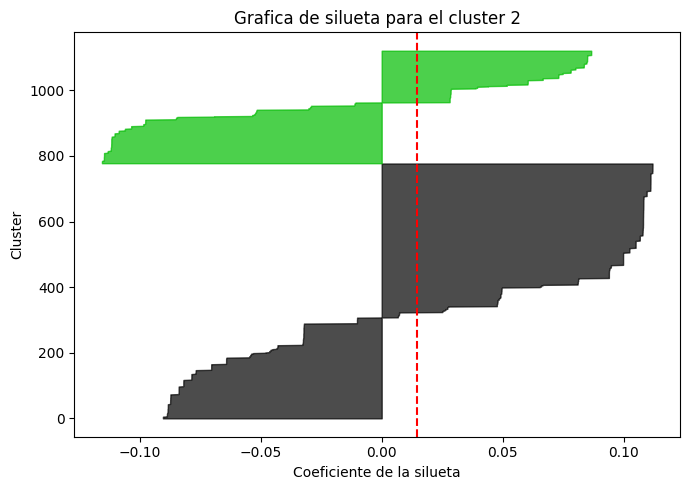

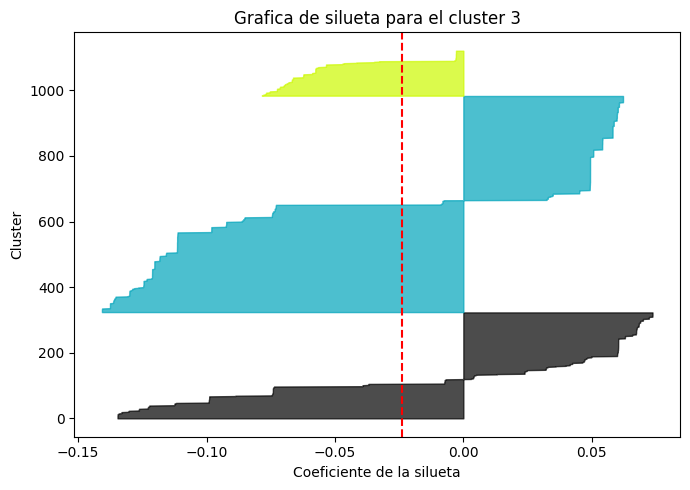

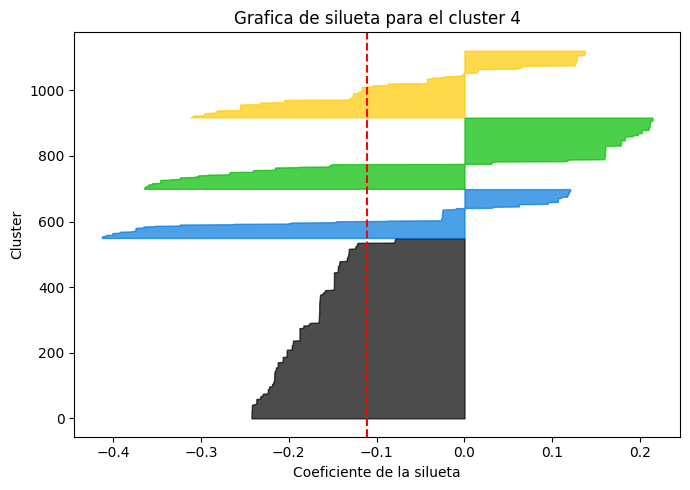

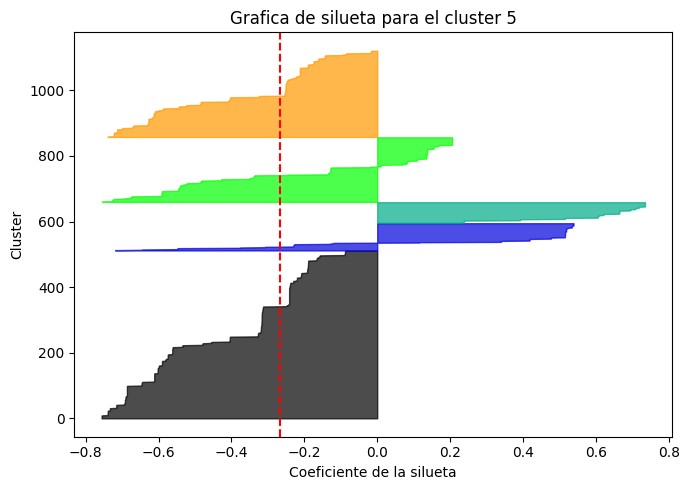

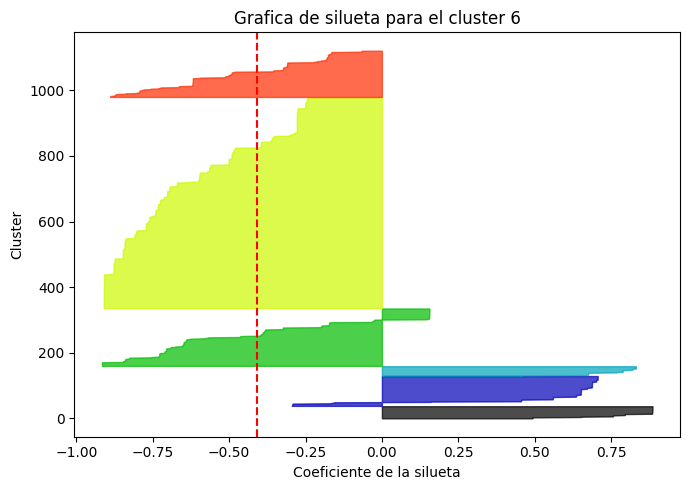

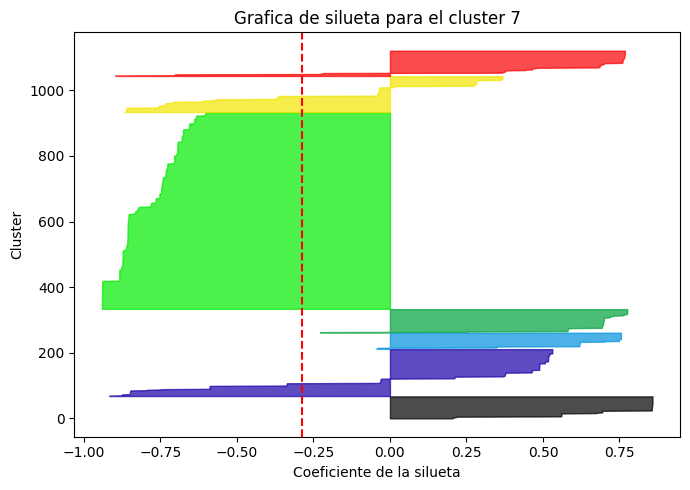

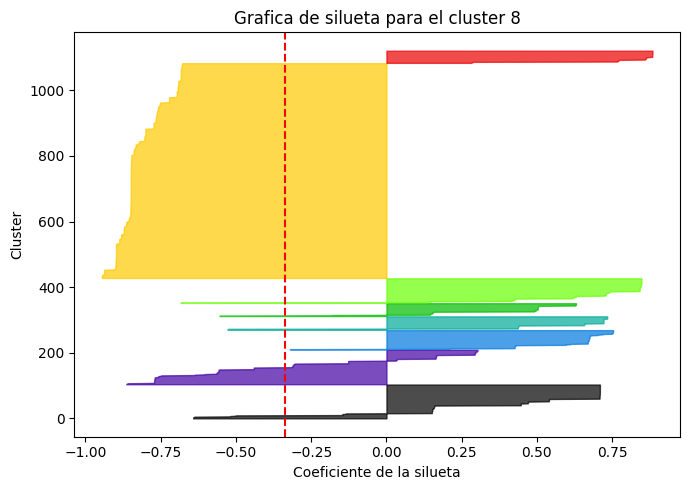

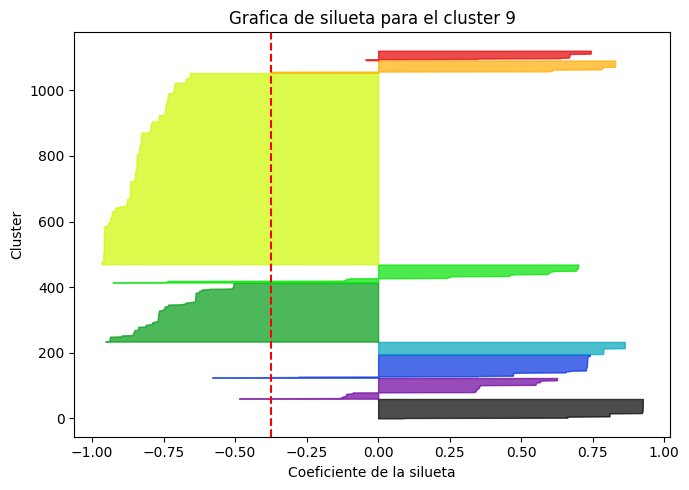

cluster = 2, Puntaje de Silueta = 0.014445864852087266
cluster = 3, Puntaje de Silueta = -0.02399870010619566
cluster = 4, Puntaje de Silueta = -0.11100794624645156
cluster = 5, Puntaje de Silueta = -0.2665343734675918
cluster = 6, Puntaje de Silueta = -0.4083839375857234
cluster = 7, Puntaje de Silueta = -0.28653341209032906
cluster = 8, Puntaje de Silueta = -0.3370494386785572
cluster = 9, Puntaje de Silueta = -0.37532965894921255


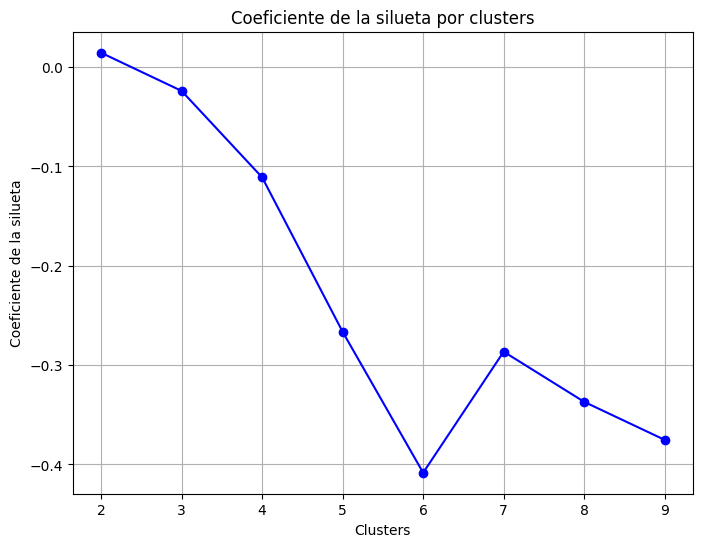

In [6]:
# Con data frame de clustering

pca = PCA(n_components=10)  
reduced_data = pca.fit_transform(df_clustering)
clusters = range(2, 10)  
puntaje_de_silueta = gmm(df_clustering, clusters)
for cluster, score in zip(clusters, puntaje_de_silueta):
    print(f'cluster = {cluster}, Puntaje de Silueta = {score}')

plot_silhouette_vs_cluster(clusters, puntaje_de_silueta)


In [7]:
def plot_component_spider_plotly(means, n_components):
    num_features = means.shape[1]
    feature_labels = [f'C {i + 1}' for i in range(num_features)]
    data = []
    for i in range(n_components):
        values = means[i].tolist() + [means[i][0]] 
        data.append(values)

    df = pd.DataFrame(data, columns=feature_labels + ['Caracteristica 1'])
    df['componente'] = [f'componente {i + 1}' for i in range(n_components)]
    df = pd.melt(df, id_vars='componente', value_vars=feature_labels, 
                 var_name='Caracteristica', value_name='Valor')
    fig = px.line_polar(df, r='Valor', theta='Caracteristica', color='componente', 
                        line_close=True, title=f'Spider Plot para {n_components} componentes')
    fig.update_traces(fill='toself', opacity=0.25)
    fig.show()
    
    
pca = PCA(n_components=10)  
reduced_data = pca.fit_transform(df_clustering)
gmm = GaussianMixture(n_components=9, random_state=42, max_iter=10000)
gmm.fit(df_clustering)
labels = gmm.predict(df_clustering)
plot_component_spider_plotly(gmm.means_,9)
score = silhouette_score(df_clustering, labels)

print(score)


0.6604722732327026


### Conclusiones del modelo GMM

El data frame usado tiene muchas caracteristicas por lo que se uso PCA para disminuirlas. Como se observa en el spider plot aun con 20 caracteristicas existe una superposicion entre cada una de los componentes, por lo que se demuestra que GMM no encontro una diferenciacion clara entre en los componentes.